In [1]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from helper.quantumScarFunctions import *

ModuleNotFoundError: No module named 'helper'

In [ ]:
dlist = np.linspace(0, 1.0, 41)
N = 8
wd = 0.6366896896896898
zavg_rn = []
yavg_rn = []
xavg_rn = []
reals = 500

dz = 0
dy = 0
dx = 0

H0_clean, eigenvalues_clean, eigenstates_clean, psi0, basisList = get_scar_ham(N)
for dz in dlist:
    rn = 0

    for _ in range(reals):
        temp = 0
        H0_dis, eigenvalues, eigenstates = get_dis_scar_ham(H0_clean, N, basisList, ham_disorder=[dz, dy, dx])

        for i in range(len(eigenvalues) - 2):
            deltaE0 = eigenvalues[i+1] - eigenvalues[i]
            deltaE1 = eigenvalues[i+2] - eigenvalues[i+1]
            temp += np.min([deltaE0, deltaE1]) / np.max([deltaE0, deltaE1])
        rn += temp / len(eigenvalues)

    zavg_rn.append(rn / reals)

dz = 0
dy = 0
dx = 0

for dy in dlist:
    rn = 0

    for _ in range(reals):
        temp = 0
        H0_dis, eigenvalues, eigenstates = get_dis_scar_ham(H0_clean, N, basisList, ham_disorder=[dz, dy, dx])

        for i in range(len(eigenvalues) - 2):
            deltaE0 = eigenvalues[i+1] - eigenvalues[i]
            deltaE1 = eigenvalues[i+2] - eigenvalues[i+1]
            temp += np.min([deltaE0, deltaE1]) / np.max([deltaE0, deltaE1])
        rn += temp / len(eigenvalues)

    yavg_rn.append(rn / reals)

dz = 0
dy = 0
dx = 0

for dx in dlist:
    rn = 0

    for _ in range(reals):
        temp = 0
        H0_dis, eigenvalues, eigenstates = get_dis_scar_ham(H0_clean, N, basisList, ham_disorder=[dz, dy, dx])

        for i in range(len(eigenvalues) - 2):
            deltaE0 = eigenvalues[i+1] - eigenvalues[i]
            deltaE1 = eigenvalues[i+2] - eigenvalues[i+1]
            temp += np.min([deltaE0, deltaE1]) / np.max([deltaE0, deltaE1])
        rn += temp / len(eigenvalues)

    xavg_rn.append(rn / reals)

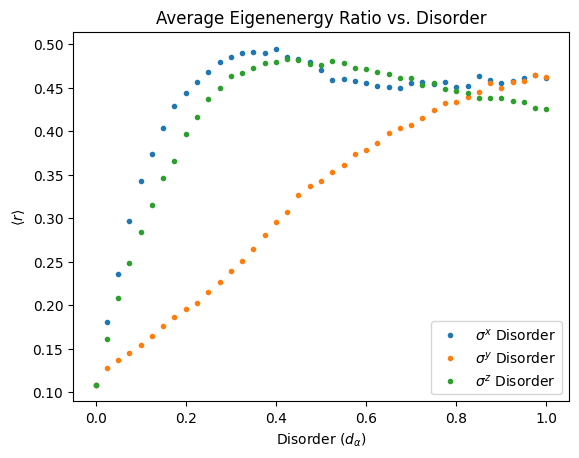

In [ ]:
plt.xlabel(r"Disorder ($d_{\alpha}$)")
plt.ylabel(r"$\langle r \rangle$")
plt.title("Average Eigenenergy Ratio vs. Disorder")
plt.plot(dlist, xavg_rn, ".", label=r"$\sigma^x$ Disorder")
plt.plot(dlist, yavg_rn, ".", label=r"$\sigma^y$ Disorder")
plt.plot(dlist, zavg_rn, ".", label=r"$\sigma^z$ Disorder")
plt.legend()
plt.savefig(f"figures/rn_N{N}.pdf")
plt.show()